In [1]:
# 추론에 필요한 라이브러리를 불러오고 모델 경로를 설정합니다

import os
import cv2
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
from transformers import ViTForImageClassification, ViTImageProcessor
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

BASE = r"C:\Users\user\Desktop\deepfake-detector"

CONFIG = {
    "model_name"       : "google/vit-base-patch16-224-in21k",
    # 이미지 모델 경로
    "image_model_path" : os.path.join(BASE, "models", "openfake", "best_model.pth"),
    # 영상 모델 경로
    "video_model_path" : os.path.join(BASE, "models", "vidprom", "best_model.pth"),
    # 영상 추론 시 추출할 프레임 수
    "frames_to_sample" : 32,
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")
print("설정 완료!")

device: cuda
설정 완료!


In [2]:
# 이미지 모델과 영상 모델을 각각 로드합니다
# 두 모델 모두 ViT 기반이라 구조는 동일하고 가중치만 달라요

processor = ViTImageProcessor.from_pretrained(CONFIG["model_name"])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
])

def load_model(model_path):
    # 모델 구조 생성 후 저장된 가중치 로드
    model = ViTForImageClassification.from_pretrained(
        CONFIG["model_name"],
        num_labels=2,
        ignore_mismatched_sizes=True
    )
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    return model

print("이미지 모델 로드 중...")
image_model = load_model(CONFIG["image_model_path"])
print("영상 모델 로드 중...")
video_model = load_model(CONFIG["video_model_path"])
print("두 모델 로드 완료!")

이미지 모델 로드 중...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


영상 모델 로드 중...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


두 모델 로드 완료!


In [3]:
# 이미지 파일 경로를 입력받아 Real/Fake 여부와 확률을 출력합니다
# 결과 이미지도 함께 시각화합니다

def predict_image(image_path):
    if not os.path.exists(image_path):
        print(f"파일을 찾을 수 없습니다: {image_path}")
        return

    # 이미지 로드 및 전처리
    img = Image.open(image_path).convert("RGB")
    input_tensor = eval_transform(img).unsqueeze(0).to(device)

    # 추론
    with torch.no_grad():
        outputs = image_model(pixel_values=input_tensor)
        probs   = torch.softmax(outputs.logits, dim=1)[0]
        pred    = probs.argmax().item()

    real_prob = probs[0].item()
    fake_prob = probs[1].item()
    label     = "FAKE" if pred == 1 else "REAL"
    color     = "red" if pred == 1 else "green"

    # 결과 출력
    print(f"\n{'='*40}")
    print(f"  판별 결과: {label}")
    print(f"  Real 확률: {real_prob*100:.2f}%")
    print(f"  Fake 확률: {fake_prob*100:.2f}%")
    print(f"{'='*40}")

    # 시각화
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # 원본 이미지
    axes[0].imshow(img)
    axes[0].set_title(f"입력 이미지", fontsize=11)
    axes[0].axis("off")

    # 확률 막대
    axes[1].barh(["Real", "Fake"], [real_prob, fake_prob],
                 color=["green", "red"], alpha=0.7)
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel("확률")
    axes[1].set_title(f"판별 결과: {label}", fontsize=13, color=color, fontweight="bold")
    for i, v in enumerate([real_prob, fake_prob]):
        axes[1].text(v + 0.01, i, f"{v*100:.2f}%", va="center", fontsize=11)

    plt.tight_layout()
    plt.show()

print("이미지 추론 함수 정의 완료!")

이미지 추론 함수 정의 완료!


In [4]:
# 영상 파일 경로를 입력받아 균등하게 프레임을 추출합니다
# 각 프레임을 영상 모델로 판별하고 전체 결과를 종합해서 출력합니다

def predict_video(video_path):
    if not os.path.exists(video_path):
        print(f"파일을 찾을 수 없습니다: {video_path}")
        return

    # 영상에서 균등하게 프레임 추출
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps          = cap.get(cv2.CAP_PROP_FPS)
    duration     = total_frames / fps if fps > 0 else 0

    # 균등 간격으로 프레임 인덱스 선택
    indices = np.linspace(0, total_frames - 1, CONFIG["frames_to_sample"], dtype=int)

    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(Image.fromarray(frame_rgb))
    cap.release()

    if not frames:
        print("프레임 추출 실패")
        return

    print(f"영상 길이: {duration:.1f}초 / 총 프레임: {total_frames} / 추출 프레임: {len(frames)}장")

    # 각 프레임 추론
    frame_probs = []
    with torch.no_grad():
        for frame in frames:
            tensor  = eval_transform(frame).unsqueeze(0).to(device)
            outputs = video_model(pixel_values=tensor)
            probs   = torch.softmax(outputs.logits, dim=1)[0]
            frame_probs.append(probs[1].item())  # Fake 확률

    # 전체 프레임 평균으로 최종 판별
    avg_fake_prob = np.mean(frame_probs)
    avg_real_prob = 1 - avg_fake_prob
    label         = "FAKE" if avg_fake_prob >= 0.5 else "REAL"
    color         = "red" if avg_fake_prob >= 0.5 else "green"

    print(f"\n{'='*40}")
    print(f"  판별 결과: {label}")
    print(f"  Real 확률: {avg_real_prob*100:.2f}%")
    print(f"  Fake 확률: {avg_fake_prob*100:.2f}%")
    print(f"{'='*40}")

    # 프레임별 결과 시각화
    fig, axes = plt.subplots(2, 1, figsize=(12, 6))

    # 추출된 프레임 썸네일
    thumb_count = min(8, len(frames))
    fig2, thumb_axes = plt.subplots(1, thumb_count, figsize=(14, 2))
    for i in range(thumb_count):
        prob = frame_probs[i]
        thumb_axes[i].imshow(frames[i])
        thumb_axes[i].set_title(f"F{i+1}\n{prob*100:.0f}%", fontsize=8,
                                color="red" if prob >= 0.5 else "green")
        thumb_axes[i].axis("off")
    fig2.suptitle("프레임별 Fake 확률", fontsize=11)
    plt.tight_layout()
    plt.show()

    # 프레임별 확률 추이
    fig3, ax = plt.subplots(figsize=(10, 3))
    ax.plot(range(1, len(frame_probs)+1), frame_probs, marker="o", color="coral", label="Fake 확률")
    ax.axhline(0.5, color="gray", linestyle="--", label="판단 기준 (0.5)")
    ax.fill_between(range(1, len(frame_probs)+1), frame_probs, 0.5,
                    where=[p >= 0.5 for p in frame_probs], alpha=0.3, color="red")
    ax.fill_between(range(1, len(frame_probs)+1), frame_probs, 0.5,
                    where=[p < 0.5 for p in frame_probs], alpha=0.3, color="green")
    ax.set_ylim(0, 1)
    ax.set_xlabel("프레임")
    ax.set_ylabel("Fake 확률")
    ax.set_title(f"최종 판별: {label}  (평균 Fake {avg_fake_prob*100:.2f}%)",
                 fontsize=12, color=color, fontweight="bold")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("영상 추론 함수 정의 완료!")

영상 추론 함수 정의 완료!


영상 길이: 5.1초 / 총 프레임: 122 / 추출 프레임: 32장

  판별 결과: REAL
  Real 확률: 99.76%
  Fake 확률: 0.24%


C:\Users\user\AppData\Local\Temp\ipykernel_9768\2993314224.py:67: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_9768\2993314224.py:67: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_9768\2993314224.py:67: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_9768\2993314224.py:67: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_9768\2993314224.py:67: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_9768\2993314224.py:67: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) 

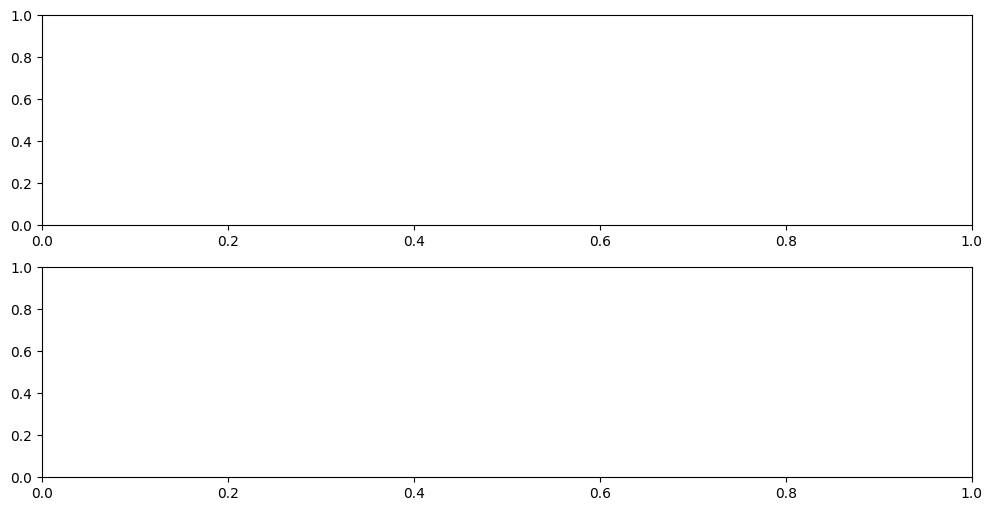

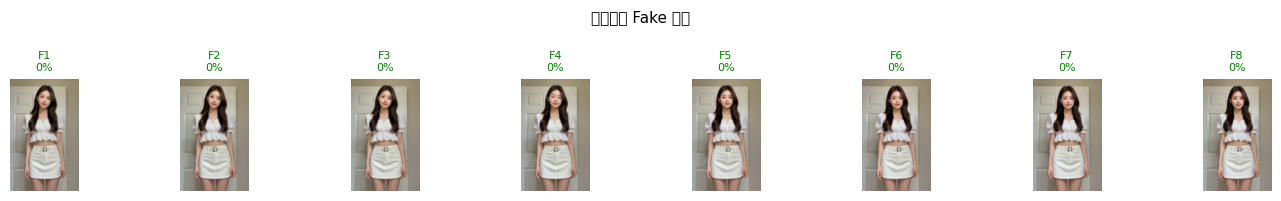

C:\Users\user\AppData\Local\Temp\ipykernel_9768\2993314224.py:85: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_9768\2993314224.py:85: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_9768\2993314224.py:85: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_9768\2993314224.py:85: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_9768\2993314224.py:85: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_9768\2993314224.py:85: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) De

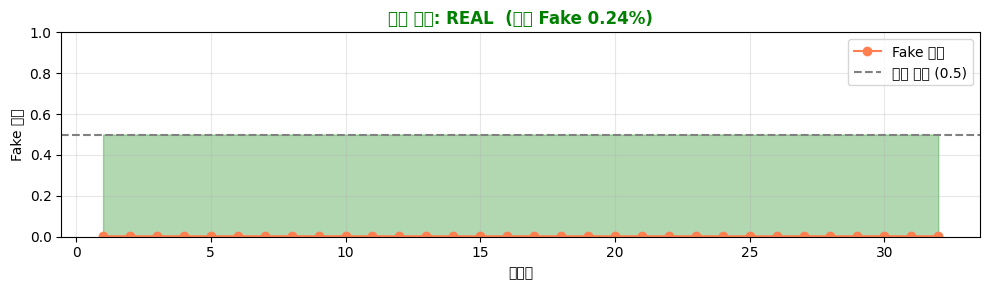

In [6]:
# -----------------------------------------------
# 이미지 테스트: 경로만 바꿔서 실행하세요
# -----------------------------------------------
# image_path = r"C:\Users\user\Desktop\test_image.jpg"
# predict_image(image_path)

# -----------------------------------------------
# 영상 테스트: 경로만 바꿔서 실행하세요
# -----------------------------------------------
video_path = r"C:\Users\user\Desktop\deepfake-detector\test_samples\video\fake\test_video.mp4"
predict_video(video_path)